In [216]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import base_functions
importlib.reload(base_functions);

Read the time series data and order it

In [217]:
data = pd.read_excel('amazon_revenue_profit-non stationary.xlsx')

# Ordering data in the inverse order (ascending order)
data = data.iloc[::-1].reset_index(drop = True)

data['Quarter'] = pd.to_datetime(data['Quarter'])

Check the raw data for stationarity and plot the time series.

Observation: The time series is not stationary, it exhibits a visible upward trend, and the ADF test indicates non stationarity

In [218]:
print('Raw data')
result = base_functions.is_stationary(data['Revenue'])

print('ADF test result:')
print('Test Statistic result: ', result[0])
print('p-value:               ', result[1])
print('Critical Values:       ', result[4])

base_functions.line_plot(data[['Quarter','Revenue']])

Raw data
ADF test result:
Test Statistic result:  5.090085181861934
p-value:                1.0
Critical Values:        {'1%': -3.5552728880540942, '5%': -2.9157312396694217, '10%': -2.5956695041322315}


Check the ACF (AutoCorrelation Function) of the raw data to identify if there is correlation between the time series and its lagged version.

Observation: High positive values ==> High correlation between the time series and its lagged version (presence of a trend)

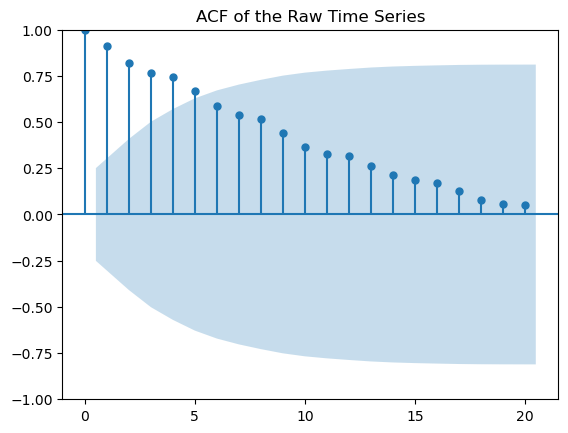

In [219]:
# Plot the Autocorrelation Function (ACF)
plot_acf(data['Revenue'], lags=20, title="ACF of the Raw Time Series")
plt.show()

First step: Start the transformation of the time series to stationary time series. We start by shrinking the time series using log

In [220]:
method = 'log'
print('After transformation to stationary using {:}'.format(method))

result_stationary = base_functions.transform_stationary(data['Revenue'], method, None)

result_stationary = result_stationary.dropna()
result = base_functions.is_stationary(result_stationary)
print('ADF test result:')
print('Test Statistic result: ', result[0])
print('p-value:               ', result[1])
print('Critical Values:       ', result[4])

base_functions.line_plot(pd.concat((data['Quarter'], result_stationary), axis = 1))

After transformation to stationary using log
ADF test result:
Test Statistic result:  -1.5895057105926689
p-value:                0.48886298586613064
Critical Values:        {'1%': -3.5552728880540942, '5%': -2.9157312396694217, '10%': -2.5956695041322315}


We don't expect the time series to become stationary after the log transformation, but we still might plot the ACF to check that.

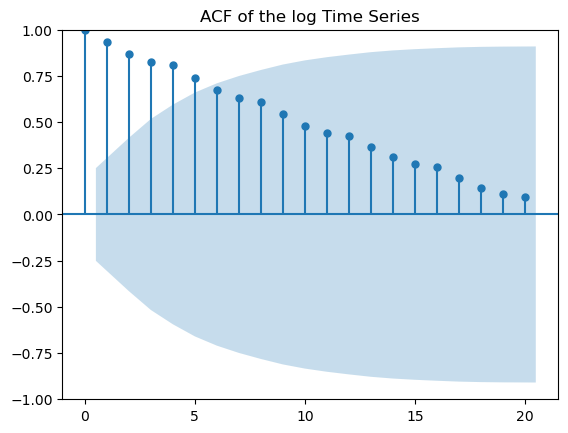

In [221]:
# Plot the Autocorrelation Function (ACF)
plot_acf(result_stationary, lags=20, title="ACF of the log Time Series")
plt.show()

Second step: Apply the diff transformation to the time series with periods = 1, to remove the upward trend 

Observation: When plotting the resulted time series we can see that the upward trend was successfully removed and now we see that we still have a seasonal pattern in the data

In [222]:
method = 'diff'

print('After transformation using {:}'.format(method))

result_stationary = base_functions.transform_stationary(result_stationary, method, 1)

result_stationary = result_stationary.dropna()

result = base_functions.is_stationary(result_stationary)

print('ADF test result:')
print('Test Statistic result: ', result[0])
print('p-value:               ', result[1])
print('Critical Values:       ', result[4])

data = pd.concat((data['Quarter'][-len(result_stationary):], result_stationary), axis = 1)
base_functions.line_plot(pd.concat((data['Quarter'], result_stationary), axis = 1))

After transformation using diff
ADF test result:
Test Statistic result:  -3.721715982689112
p-value:                0.003817863485157775
Critical Values:        {'1%': -3.5552728880540942, '5%': -2.9157312396694217, '10%': -2.5956695041322315}


Next We check with the ACF plot the transformed time series

Observation: When plotting the ACF we can see high correlation values between the time series and its lagged version of 4 lags. that applied that the time series have a seasonal pattern every quarter. Therefore, we must apply the diff with periods = 4 to remove seasonality. 

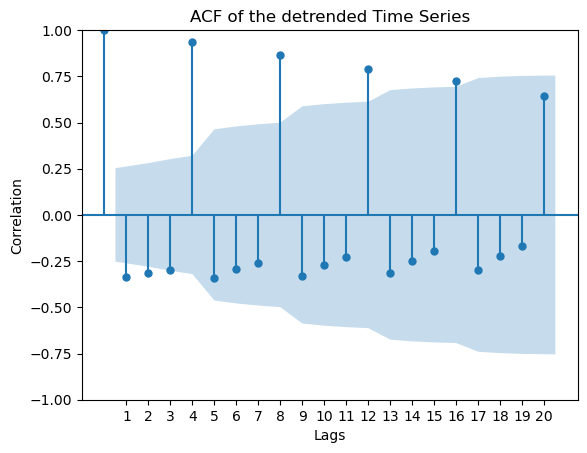

In [223]:
# Compute autocovariance for a range of lags
lags = range(1, 21)  # You can modify the range as needed

# Plot the Autocorrelation Function (ACF)
plot_acf(result_stationary, lags=20, title="ACF of the detrended Time Series")
plt.xticks(lags)
plt.xlabel('Lags')
plt.ylabel('Correlation')
plt.show()

Third step: Apply the diff transformation to the time series with periods = 4, to remove the seasonality 

Observation: When plotting the resulted time series we can see that there is no seasonal pattern neither trend pattern. So the time series is now stationary

In [224]:
method = 'diff'
print('After transformation using {:}'.format(method))

result_stationary = base_functions.transform_stationary(result_stationary, method, 4)

result_stationary = result_stationary.dropna()

result = base_functions.is_stationary(result_stationary)

print('ADF test result:')
print('Test Statistic result: ', result[0])
print('p-value:               ', result[1])
print('Critical Values:       ', result[4])

data = pd.concat((data['Quarter'][-len(result_stationary):].reset_index(drop=True), result_stationary.reset_index(drop=True)), axis = 1)

base_functions.line_plot(pd.concat((data['Quarter'], result_stationary), axis = 1))

After transformation using diff
ADF test result:
Test Statistic result:  -4.914449455832012
p-value:                3.268481539055942e-05
Critical Values:        {'1%': -3.562878534649522, '5%': -2.918973284023669, '10%': -2.597393446745562}


Lastely We check with the ACF plot the transformed time series

Observation: When plotting the ACF we can see insignificant values of correlation. So time series is no longer correlated with its lagged version.

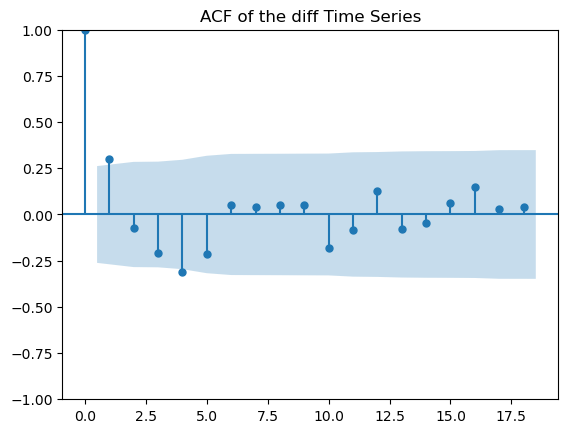

In [225]:
# Plot the Autocorrelation Function (ACF)
plot_acf(result_stationary, title="ACF of the diff Time Series")
plt.show()